In [1]:
import os
import glob
import json
import yaml
import numpy as np
import torch
import argparse

import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
sys.path+=[abs_path, f'{abs_path}/utils']
from evaluation import Options, Trainer

import trimesh
from utils import ICT_face_model, YamlArgParser
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
config = f'{abs_path}/config/train.yml'
opts_yaml = yaml.load(open(config), Loader=yaml.FullLoader)
opts = argparse.Namespace(**opts_yaml)

opts.NFR = False
opts.dec_type = 'disp'
# opts.ckpt = '../ckpt_stage1/2024-08-18-23-32-29-all' ## ------> load checkpoint
# opts.ckpt = '../ckpt_stage1/2024-07-08-06-27-12-all'
# opts.ckpt = '../ckpt_stage1/2024-09-06-08-01-39-all'; opts.seg_dim=24
opts.ckpt = '../ckpt_stage1/2024-08-27-05-34-44-all'; opts.seg_dim=24

opts.design = 'new2'

opts.device="cuda:0"

opts.data_rand_trans=False
opts.data_rand_scale=False
opts.learn_rig_emb=False
opts.use_decimate = False
opts.stage1 = True
opts.scale_exp = 1.0


trainer = Trainer(opts)

[DiffusionNet] causion: no pre_computes provided!
[DiffusionNet] causion: no pre_computes provided!
[DiffusionNet] causion: no pre_computes provided!
===========< NFS >===========
[mesh_decoder]: 	601859
[mesh_id_encoder]: 	1906560
[mesh_exp_encoder]: 	1906560
[mesh_seg_encoder]: 	1879832
-------------------------------
[total]: 	6833243
Loading... ../ckpt_stage1/2024-08-27-05-34-44-all/wav2rig_best.pth


(11248, 3)


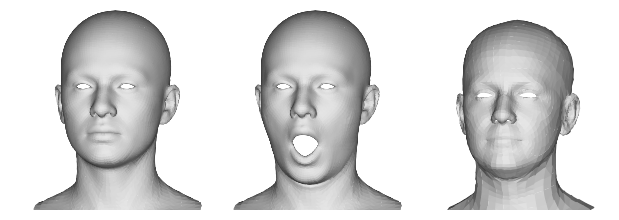

In [3]:
## full head
ict_face_model = ICT_face_model()
ict_tri = ict_face_model.get_mesh()

## flame
flame_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)


## ICT random expression
bs_coeff = np.eye(53)[26]
vertices = torch.from_numpy(ict_tri.vertices + ict_face_model.get_exp_disp(bs_coeff))
src_mesh = ict_tri
tgt_mesh = flame_tri


print(ict_tri.vertices.shape)

M_SCALE = 0.68
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces ]
SIZE=2

plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [4]:
pred_outputs = trainer.model.inference(
    gt_vertices=vertices, 
    src_mesh=src_mesh, 
    tgt_mesh=tgt_mesh
)

decoding...: 100%|██████████| 1/1 [00:00<00:00, 490.73it/s]


 source neutral 	|	 source expression 	|	 target neutral 	|	 target expression


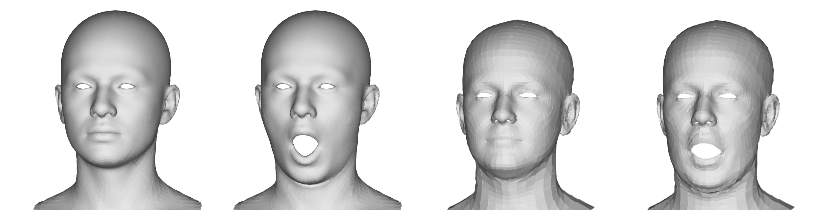

In [5]:
v_list=[ ict_tri.vertices * M_SCALE, vertices[0] * M_SCALE, flame_tri.vertices * M_SCALE, pred_outputs.detach().cpu().numpy()[0] * M_SCALE ]
f_list=[ ict_tri.faces, ict_tri.faces, flame_tri.faces, flame_tri.faces ]

print(' source neutral \t|\t source expression \t|\t target neutral \t|\t target expression')
plot_image_array(
    v_list, f_list,
    rot_list=[[0,-10,0]]*len(v_list), 
    size=SIZE, bg_black=False, mode='shade', 
    logdir=f"_tmp/train", 
    name=f"test", save=False
)

In [6]:
try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *
import pickle

(5223, 3)


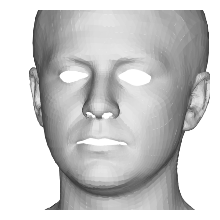

decoding...: 100%|██████████| 1/1 [00:00<00:00, 535.47it/s]

torch.Size([1, 5223, 24])


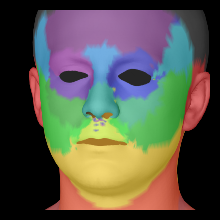

In [9]:
dummy_tri = trimesh.load(f'/data/sihun/multiface_align/obj/m--20181017--0000--002914589--GHS_mesh.obj', process=False, maintain_order=True)
with open(f"/data/sihun/multiface_align/mf_templates.pkl",'rb') as f:
    _mesh_pkl = pickle.load(f)

# dummy_tri = trimesh.load(f'/data/sihun/BIWI_align_deci/BIWI.ply', process=False, maintain_order=True)
# with open(f"/data/sihun/BIWI_align_deci/templates_align_deci.pkl",'rb') as f:
#     _mesh_pkl = pickle.load(f)

    
# dummy_tri.vertices*=0
dummy_vertices=[]
cnt=0
# for key in mf_mesh_pkl.keys():
for key in _mesh_pkl.keys():
    if key=='face':
        continue
    cnt+=1
    # dummy_tri.vertices+=_mesh_pkl[key]
    dummy_vertices.append(_mesh_pkl[key][None])
    
dummy_vertices = np.vstack(dummy_vertices).mean(0)
# dummy_vertices = dummy_vertices[0][0]
print(dummy_vertices.shape)
dummy_tri.vertices =dummy_vertices
# dummy_tri.vertices +=np.array([0,-0.2,0])
# dummy_tri.faces = mf_mesh_pkl['face']
dummy_tri.faces = _mesh_pkl['face']

plot_image_array(
        [dummy_tri.vertices], [dummy_tri.faces], 
        rot_list=[[0,-10,0]] * 2, 
        size=SIZE, bg_black=False, mode='shade', 
        logdir=f"_tmp/train", 
        name=f"test", save=False
    )


M_SCALE = 30
SIZE=2
pred_outputs, pred_seg1 = trainer.model.inference(
    gt_vertices=torch.tensor(dummy_tri.vertices)[None], 
    src_mesh=dummy_tri,
    tgt_mesh=dummy_tri,
    return_seg=True
)
print(pred_seg.shape)
c_list=[ np.eye(pred_seg.shape[-1])[torch.nn.Softmax(dim=-1)(pred_seg.detach().cpu()[0]).numpy().argmax(-1)] ]
# c_list=[ pred_seg.detach().cpu()[0].numpy() ]
plot_mesh_gouraud([ dummy_tri.vertices ], [ dummy_tri.faces], c_list, is_color=False,
                     # is_diff=True, diff_base=v_list[0], #diff_revert=True,
                     rot_list=[[0,-10,0]], size=SIZE, mode='shade')

In [ ]:
# import igl
# ccc = c_list[0].copy()

# L = igl.cotmatrix(dummy_tri.vertices, dummy_tri.faces)
# B = L@L
# for i in range(1):
#     diff_c = B @ ccc
#     #diff_c = B @ ccc
#     ccc = ccc*.12 + diff_c*0.8
# # c_list[0].shape
# plot_mesh_gouraud([ dummy_tri.vertices ], [ dummy_tri.faces], [ccc], is_color=False,
#                      # is_diff=True, diff_base=v_list[0], #diff_revert=True,
#                      rot_list=[[0,-10,0]], size=SIZE, mode='shade')

In [10]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import igl

# -------------------------------------------
# Helpers
# -------------------------------------------
def one_hot_from_labels(labels, num_classes):
    N = labels.shape[0]
    Y = np.zeros((N, num_classes), dtype=np.float64)
    Y[np.arange(N), labels] = 1.0
    return Y

def labels_from_scores(scores):
    return scores.argmax(axis=1).astype(np.int32)

def normalize_rows(x, eps=1e-12):
    s = x.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return x / s

def build_k_ring_adj(F, N, k=1):
    """Return list of numpy arrays with k-ring neighbors for each vertex."""
    one_ring = igl.adjacency_list(F)
    if k == 1:
        return [np.array(nbrs, dtype=np.int32) for nbrs in one_ring]

    k_adj = []
    for v in range(N):
        ring = set(one_ring[v])
        frontier = set(ring)
        for _ in range(2, k+1):
            nxt = set()
            for u in frontier:
                nxt.update(one_ring[u])
            nxt.discard(v)
            frontier = nxt - ring
            ring.update(frontier)
        k_adj.append(np.fromiter(ring, dtype=np.int32))
    return k_adj

# -------------------------------------------
# Method A: Diffusion smoothing on N×S scores
# -------------------------------------------
def smooth_scores_diffuse(V, F, Y_onehot, lam=1e-2, mass_type="voronoi",
                          clamp_nonneg=True, renormalize=True):
    """
    Inputs
      V: (N,3)
      F: (M,3) int
      Y_onehot: (N,S) one-hot/score matrix (rows ideally sum to 1)
      lam: Tikhonov parameter
    Returns
      X_soft: (N,S) smoothed scores (row-stochastic if renormalize=True)
      hard_labels: (N,) argmax
      X_hard_onehot: (N,S) one-hot from argmax
    """
    N, S = Y_onehot.shape

    # cot-Laplacian: igl.cotmatrix returns negative semi-definite by convention
    L = -igl.cotmatrix(V, F)  # positive semi-definite
    # Mass matrix
    try:
        M = igl.massmatrix(
            V, F,
            igl.MASSMATRIX_TYPE_VORONOI if mass_type == "voronoi"
            else igl.MASSMATRIX_TYPE_BARYCENTRIC
        )
    except TypeError:
        M = igl.massmatrix(V, F)  # fallback (usually Voronoi)

    A = (L + lam * M).tocsr()
    B = (lam * M) @ sp.csr_matrix(Y_onehot)

    # Factorize once, solve for all S RHS
    solver = spla.factorized(A.tocsc())
    X_cols = [solver(B[:, j].toarray().ravel()) for j in range(S)]
    X_soft = np.stack(X_cols, axis=1)

    if clamp_nonneg:
        X_soft = np.maximum(X_soft, 0.0)
    if renormalize:
        X_soft = normalize_rows(X_soft)

    hard_labels = labels_from_scores(X_soft)
    X_hard = one_hot_from_labels(hard_labels, S)
    return X_soft, hard_labels, X_hard

# -------------------------------------------
# Method B: k-ring majority vote on hard labels
# -------------------------------------------
def smooth_labels_mode(V, F, Y_onehot, k=1, iters=3, self_weight=1.0):
    """
    Iterative k-ring majority vote on hard labels.
    Inputs
      V: (N,3), F: (M,3)
      Y_onehot: (N,S)
    Returns
      hard_labels: (N,)
      Y_hard_onehot: (N,S)
    """
    N, S = Y_onehot.shape
    labels = Y_onehot.argmax(axis=1).astype(np.int32)

    # k-ring adjacency
    one_ring = igl.adjacency_list(F)
    if k == 1:
        adj = [np.asarray(n, dtype=np.int32) for n in one_ring]
    else:
        adj = []
        for v in range(N):
            ring = set(one_ring[v])
            frontier = set(ring)
            for _ in range(2, k + 1):
                nxt = set()
                for u in frontier:
                    nxt.update(one_ring[u])
                nxt.discard(v)
                frontier = nxt - ring
                ring.update(frontier)
            adj.append(np.fromiter(ring, dtype=np.int32))

    x = labels.copy()
    for _ in range(iters):
        new_x = x.copy()
        for v in range(N):
            nbrs = adj[v]
            if nbrs.size == 0:
                continue

            votes, counts = np.unique(x[nbrs], return_counts=True)
            # <<< FIX: float 캐스팅으로 가중치 더하기 허용 >>>
            counts = counts.astype(float, copy=False)

            # 자기 라벨 가중치로 안정화
            if self_weight > 0:
                if x[v] in votes:
                    counts[votes == x[v]] += float(self_weight)
                else:
                    votes = np.append(votes, x[v])
                    counts = np.append(counts, float(self_weight))

            # tie-break: 동일 최대일 때 자기 라벨을 우선
            maxc = counts.max()
            idxs = np.flatnonzero(counts == maxc)
            if idxs.size > 1:
                # 자기 라벨이 후보에 있으면 선택
                self_idx = np.flatnonzero(votes[idxs] == x[v])
                new_x[v] = votes[idxs[self_idx[0]]] if self_idx.size > 0 else votes[idxs[0]]
            else:
                new_x[v] = votes[idxs[0]]
        x = new_x

    hard_labels = x.astype(np.int32)
    Y_hard = np.zeros((N, S), dtype=np.float64)
    Y_hard[np.arange(N), hard_labels] = 1.0
    return hard_labels, Y_hard


# -------------------------------------------
# Convenience wrapper
# -------------------------------------------
def denoise_vertex_segmentation(V, F, Y_onehot,
                                method="diffuse",
                                lam=5e-3,
                                k=1, iters=3, self_weight=1.0):
    """
    method in {'diffuse','mode'}
    """
    if method == "diffuse":
        X_soft, hard_labels, Y_hard = smooth_scores_diffuse(
            V, F, Y_onehot, lam=lam
        )
        return dict(soft_scores=X_soft, hard_labels=hard_labels, hard_onehot=Y_hard)
    elif method == "mode":
        hard_labels, Y_hard = smooth_labels_mode(
            V, F, Y_onehot, k=k, iters=iters, self_weight=self_weight
        )
        return dict(soft_scores=None, hard_labels=hard_labels, hard_onehot=Y_hard)
    else:
        raise ValueError("method must be 'diffuse' or 'mode'")

# -------------------------------------------
# Example usage (replace with your data)
# -------------------------------------------
# if __name__ == "__main__":
#     # V, F = igl.read_triangle_mesh("mesh.obj")
#     # Y_onehot = np.load("vertex_onehot.npy")   # shape (N,S), rows one-hot
#     # res = denoise_vertex_segmentation(V, F, Y_onehot, method="diffuse", lam=1e-2)
#     # or:
#     # res = denoise_vertex_segmentation(V, F, Y_onehot, method="mode", k=2, iters=3)
#     pass


[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


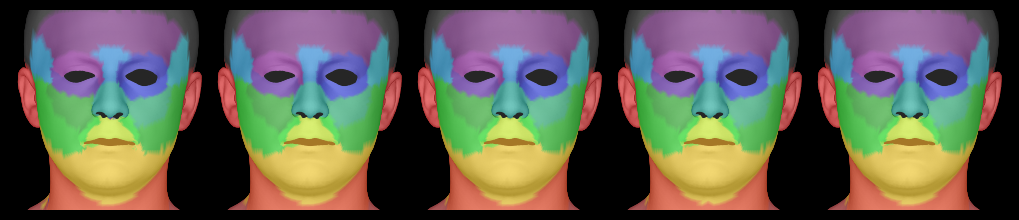

In [11]:


Y = c_list[0].copy()
# Y = pred_seg.detach().cpu()[0].numpy()
# Y = torch.nn.Softmax(dim=-1)(pred_seg.detach().cpu()[0]).numpy()
print(Y)
C_list = [Y]

## X is a dictionary
X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="mode", lam=1e-5, k=1, iters=10)
# X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="diffuse", lam=1e-2)
# print(X)
X1 = X['hard_onehot']
C_list.append(X1)

X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="mode", lam=1e-5, k=2, iters=3,self_weight=4)
# X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="mode", lam=1e-1, k=1)
# X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, X['hard_onehot'], method="mode", lam=1e-5, k=2, iters=10)
# X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, X['hard_onehot'], method="mode", lam=1e-5, k=2)
# X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="diffuse", lam=1e-2)
# print(X)
C_list.append(X['hard_onehot'])

X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="mode", lam=1e-5, k=3, iters=5,self_weight=9)
C_list.append(X['hard_onehot'])

X = denoise_vertex_segmentation(dummy_tri.vertices, dummy_tri.faces, Y, method="mode", lam=1e-5, k=4, iters=5,self_weight=16)
C_list.append(X['hard_onehot'])

plot_mesh_gouraud(
    [dummy_tri.vertices]*len(C_list),
    [dummy_tri.faces]*len(C_list),
    C_list,
    rot_list=[[0,0,0]]*len(C_list), size=SIZE, mode='shade')

(5223, 24)
(5223,)
[ True False False ... False False False] [False False False ... False False False]


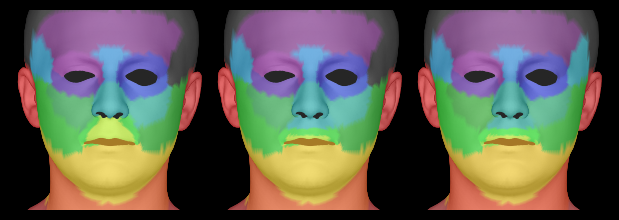

In [12]:
### for BIWI
print(C_list[-1].shape)
C_list_cp = C_list[-2].copy()


# mask = np.array([i for i in range(24) if i != 16]) ## upper lip
mask = np.array([i for i in range(24) if i != 14])## gree


# mask = np.array([i for i in range(24) if i != 17]) ## lower lip
# mask = np.array([i for i in range(24) if i != 15]) ## below lower lip

# mask = np.array([i for i in range(24) if i != 1]) # forhead
# mask = np.array([i for i in range(24) if i != 7]) ## forhead left 
# mask = np.array([i for i in range(24) if i != 8]) ## forhead right 
# mask = np.array([i for i in range(24) if i != 9])  # nose


eye_mat = np.eye(24)
mm__1 = (C_list[-2] == eye_mat[1]).all(1)
mm__7 = (C_list[-2] == eye_mat[7]).all(1)
mm__8 = (C_list[-2] == eye_mat[8]).all(1)
mm__9 = (C_list[-2] == eye_mat[9]).all(1)

mm_14 = (C_list[-2] == eye_mat[14]).all(1)
mm_16 = (C_list[-2] == eye_mat[16]).all(1)
mm_17 = (C_list[-2] == eye_mat[17]).all(1)
mm_15 = (C_list[-2] == eye_mat[15]).all(1)

axis_ =1
mm_y = (dummy_tri.vertices[:,axis_] > (dummy_tri.vertices[mm_14].mean(0)[axis_]-55e-3) )#.all(1)

mm_y_17 = (dummy_tri.vertices[:,axis_] < (dummy_tri.vertices[mm_17].mean(0)[axis_]-75e-3) )#.all(1)

mm_x = (dummy_tri.vertices[:,0] < (dummy_tri.vertices[mm_14].mean(0)[0]+21e-2) )#.all(1)
mm_x_ = (dummy_tri.vertices[:,0] > (dummy_tri.vertices[mm_14].mean(0)[0]+23e-2) )#.all(1)

mm_x_9_r = (dummy_tri.vertices[:,0] > (dummy_tri.vertices[mm__9].mean(0)[0])+35e-2 )#.all(1)
mm_x_9_l = (dummy_tri.vertices[:,0] < (dummy_tri.vertices[mm__9].mean(0)[0])-4e-1 )#.all(1)

print(mm_y.shape)
print(mm_y, mm_14)

# mmmm = mm_y & mm_16 & mm_x
# C_list_cp[mmmm] = np.eye(24)[14][None]

upper_lip = (mm_y & mm_16) | (mm_x_ & mm_16)
C_list_cp[upper_lip] = eye_mat[14][None]

lower_lip =(mm_17 & mm_y_17)
C_list_cp[lower_lip] = eye_mat[15][None]

n_mm_17 = (C_list_cp == eye_mat[17]).all(1)
n_mm_17 = n_mm_17 & mm_x_
C_list_cp[n_mm_17] = eye_mat[15][None]

temporalis_left = mm_x_9_l & mm__9
C_list_cp[temporalis_left] = eye_mat[7][None]

temporalis_right = mm_x_9_r & mm__9
C_list_cp[temporalis_right] = eye_mat[8][None]

n_mm_14 = (C_list_cp == eye_mat[14]).all(1)
n_mm_y_14 = (dummy_tri.vertices[:,1] > (dummy_tri.vertices[n_mm_14].mean(0)[1]) )#.all(1)
n_mm_14 = n_mm_y_14 & n_mm_14
C_list_cp[n_mm_14] = eye_mat[9][None]




mask = np.array([i for i in range(24) if i != 8])## gree

rep=3
plot_mesh_gouraud(
    [dummy_tri.vertices]*rep,
    [dummy_tri.faces]*rep,
    [C_list[-2][:,mask], C_list_cp[:,mask], C_list_cp],
    rot_list=[[0,0,0]]*rep, size=SIZE, mode='shade')

(5223, 24)


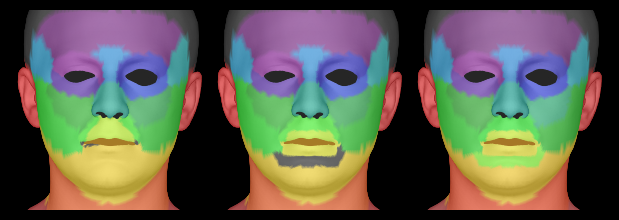

In [87]:
### for BIWI
print(C_list[-1].shape)
C_list_cp = C_list[-2].copy()


mask = np.array([i for i in range(24) if i != 16]) ## upper lip
mask = np.array([i for i in range(24) if i != 14])## gree

mask = np.array([i for i in range(24) if i != 18]) ## jaw

# mask = np.array([i for i in range(24) if i != 13]) ## left cheek

# mask = np.array([i for i in range(24) if i != 17]) ## lower lip
mask = np.array([i for i in range(24) if i != 15]) ## below lower lip

# mask = np.array([i for i in range(24) if i != 1]) # forhead
# mask = np.array([i for i in range(24) if i != 7]) ## forhead left 
# mask = np.array([i for i in range(24) if i != 8]) ## forhead right 
# mask = np.array([i for i in range(24) if i != 9])  # nose


eye_mat = np.eye(24)
mm__1 = (C_list[-2] == eye_mat[1]).all(1)
mm__7 = (C_list[-2] == eye_mat[7]).all(1)
mm__8 = (C_list[-2] == eye_mat[8]).all(1)
mm__9 = (C_list[-2] == eye_mat[9]).all(1)

mm_13 = (C_list[-2] == eye_mat[13]).all(1)

mm_15 = (C_list[-2] == eye_mat[15]).all(1)

mm_14 = (C_list[-2] == eye_mat[14]).all(1)
mm_16 = (C_list[-2] == eye_mat[16]).all(1)
mm_17 = (C_list[-2] == eye_mat[17]).all(1)
mm_15 = (C_list[-2] == eye_mat[15]).all(1)

mm_18 = (C_list[-2] == eye_mat[18]).all(1)

axis_ =1
mm_y_14 = (dummy_tri.vertices[:,axis_] > (dummy_tri.vertices[mm_14].mean(0)[axis_]-10e-3) )#.all(1)
upper_lip = (mm_y_14 & mm_16)
C_list_cp[upper_lip] = eye_mat[14][None]

mm_y_13= (dummy_tri.vertices[:,1] > (dummy_tri.vertices[mm_13].min(0)[1]-21e-3) )#.all(1)

mm_z_14= (dummy_tri.vertices[:,2] > (dummy_tri.vertices[mm_14].min(0)[2])-21e-3 )#.all(1)

mm_y_13__= (dummy_tri.vertices[:,1] > (dummy_tri.vertices[mm_13].min(0)[1]-13e-2) )#.all(1)
mm_z_14__= (dummy_tri.vertices[:,2] > (dummy_tri.vertices[mm_14].min(0)[2])-69e-3 )#.all(1)

# mm_15
C_list_cp[mm_15] = eye_mat[17][None]
below_lower_lip=mm_y_13__&mm_18 & mm_z_14__
C_list_cp[below_lower_lip] = eye_mat[15][None]


lower_lip = mm_y_13 & mm_18 & mm_z_14
C_list_cp[lower_lip] = eye_mat[17][None]

rep=3
plot_mesh_gouraud(
    [dummy_tri.vertices]*rep,
    [dummy_tri.faces]*rep,
    [C_list[-2][:,mask], C_list_cp[:,mask], C_list_cp],
    rot_list=[[0,0,0]]*rep, size=SIZE, mode='shade')

(5223, 24)
(5223, 22)


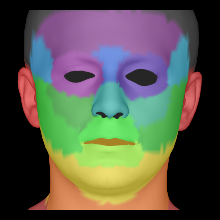

In [100]:
print(C_list_cp.shape)
C_list_cp_=np.concatenate((
    C_list_cp[:,:2],
    C_list_cp[:,2,None]+C_list_cp[:,3,None],
    C_list_cp[:,4,None]+C_list_cp[:,5,None],
    C_list_cp[:,5:14],
    C_list_cp[:,14,None]+C_list_cp[:,16,None],
    C_list_cp[:,15,None]+C_list_cp[:,17,None],
    C_list_cp[:,17:],
),axis=1)

print(C_list_cp_.shape)
rep=1
plot_mesh_gouraud(
    [dummy_tri.vertices]*rep,
    [dummy_tri.faces]*rep,
    [C_list_cp_],
    rot_list=[[0,0,0]]*rep, size=SIZE, mode='shade')

In [40]:

import torch
import numpy as np


try:
    from kmeans_pytorch import kmeans
except:
    
    import sys
    from pathlib import Path
    # abs_path = str(Path.cwd().parents[0].absolute())
    sys.path+=[f'{abs_path}/third_party/kmeans_pytorch']
    from kmeans_pytorch import kmeans
    
# data
# data_size, dims, num_clusters = 1000, 2, 3
# x = (np.random.randn(data_size, dims) / 6) * np.array([1.0, 3.0])
# x_th = torch.from_numpy(x)

num_clusters = 24
x = pred_seg.detach().cpu().numpy()
x_th = pred_seg
# x.requires_grad_(True)


device=torch.device('cuda:0')

cluster_ids_x1, cluster_centers = kmeans(
    X=pred_seg[0], num_clusters=num_clusters, distance='cosine', device=device
)

cluster_ids_x2, cluster_centers = kmeans(
    X=pred_seg1[0], num_clusters=num_clusters,
    cluster_centers=cluster_centers,
    distance='cosine', device=device
)

cluster_ids_x1_eye = torch.eye(num_clusters)[cluster_ids_x1]
cluster_ids_x2_eye = torch.eye(num_clusters)[cluster_ids_x2] 

# kmeans
# cluster_ids_x, cluster_centers = kmeans(
# #     X=x_th, num_clusters=num_clusters, distance='euclidean', device=torch.device('cuda:0')
#     X=x_th, num_clusters=num_clusters, distance='cosine', device=torch.device('cuda:0')
# )
# cluster_ids_x2, cluster_centers2 = kmeans(
#     X=x_th, num_clusters=num_clusters, distance='euclidean', device=torch.device('cuda:0')
# )

running k-means on cuda:0..


[running kmeans]: 22it [00:00, 241.35it/s, center_shift=0.000000, iteration=22, tol=0.000100]   


running k-means on cuda:0..
resuming


[running kmeans]: 18it [00:00, 249.27it/s, center_shift=0.000000, iteration=18, tol=0.000100] 


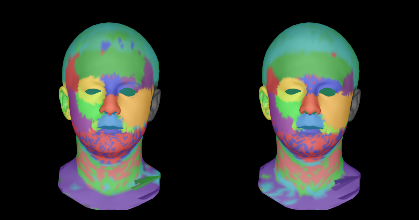

In [43]:
# cluster_ids_x2.shape
# cluster_ids_x1_eye.shape
rep=2
v_list = [dummy_tri.vertices]*rep
f_list = [dummy_tri.faces]*rep
c_list = [cluster_ids_x1_eye.numpy(), cluster_ids_x2_eye.numpy()]

plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,0,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')
# plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,40,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')
# plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,90,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')

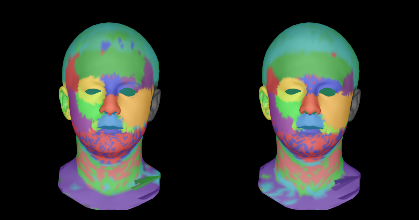

In [42]:
# cluster_ids_x2.shape
# cluster_ids_x1_eye.shape
rep=2
v_list = [dummy_tri.vertices]*rep
f_list = [dummy_tri.faces]*rep
c_list = [cluster_ids_x1_eye.numpy(), cluster_ids_x2_eye.numpy()]

plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,0,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')
# plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,40,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')
# plot_mesh_gouraud(v_list, f_list, c_list, rot_list=[[0,90,0]]*rep, mesh_scale=0.55, size=SIZE, mode='shade')

In [33]:
# git clone https://github.com/subhadarship/kmeans_pytorch
# cd kmeans_pytorch
# pip install --editable .

In [ ]:
# plot
plt.figure(figsize=(4, 3), dpi=160)
plt.scatter(x[:, 0], x[:, 1], c=cluster_ids_x, cmap='cool')
# plt.scatter(x[:, 0], x[:, 1], c=cluster_ids_x, cmap='cool', marker='X')
plt.scatter(
    cluster_centers[:, 0], cluster_centers[:, 1],
    c='white',
    alpha=0.6,
    edgecolors='black',
    linewidths=2
)
plt.scatter(
    cluster_centers2[:, 0], cluster_centers2[:, 1],
    c='red',
    alpha=0.6,
    edgecolors='black',
    linewidths=2
)
plt.axis([-1, 1, -1, 1])
plt.tight_layout()
plt.show()

In [115]:
# np.save('biwi_seg_24.npy', C_list_cp)
C_list_cp.shape

(5223, 24)

In [88]:
np.save('mf_seg_24.npy', C_list_cp)


decoding...: 100%|██████████| 1/1 [00:00<00:00, 629.40it/s]


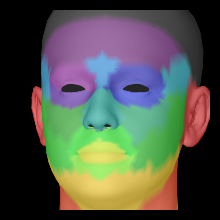

In [76]:
####
## flame
M_SCALE = 30
SIZE=2
dummy_tri = trimesh.load(f'{abs_path}/test-mesh/flame_final_transformed.obj', process=False, maintain_order=True)
# dummy_tri = trimesh.load(f'/data/sihun/multiface_align/obj/m--20181017--0000--002914589--GHS_mesh.obj', process=False, maintain_order=True)

pred_outputs, pred_seg = trainer.model.inference(
    gt_vertices=torch.tensor(dummy_tri.vertices)[None], 
    src_mesh=dummy_tri,
    tgt_mesh=dummy_tri,
    return_seg=True
)
c_list=[ np.eye(pred_seg.shape[-1])[torch.nn.Softmax(dim=-1)(pred_seg.detach().cpu()[0]).numpy().argmax(-1)] ]
# c_list=[ pred_seg.detach().cpu()[0].numpy() ]
plot_mesh_gouraud([ dummy_tri.vertices ], [ dummy_tri.faces], c_list, is_color=False,
                     # is_diff=True, diff_base=v_list[0], #diff_revert=True,
                     rot_list=[[0,-10,0]], size=SIZE, mode='shade')
# plot_image_array_seg(
#     [ dummy_tri.vertices ], [ dummy_tri.faces], c_list, 
#     rot_list=[[0,-10,0]] * 2, 
#     size=SIZE, bg_black=False, mode='shade', 
#     logdir=f"_tmp/train", 
#     name=f"test", save=False
# )



# with open(f"/data/sihun/VOCA-COMA/voca_templates.pkl",'rb') as f:
#     voca_mesh_pkl = pickle.load(f)
# dummy_tri.faces = voca_mesh_pkl['face']

# for key in voca_mesh_pkl.keys():
#     if key=='face':
#         continue
#     dummy_tri.vertices = voca_mesh_pkl[key]
    
#     pred_outputs, pred_seg = trainer.model.inference(
#         gt_vertices=torch.tensor(dummy_tri.vertices)[None], 
#         src_mesh=dummy_tri,
#         tgt_mesh=dummy_tri,
#         return_seg=True
#     )
#     c_list=[ pred_seg.detach().cpu()[0] ]

#     plot_image_array_seg(
#         [ dummy_tri.vertices ], [ dummy_tri.faces], c_list, 
#         rot_list=[[0,-10,0]] * 2, 
#         size=SIZE, bg_black=False, mode='shade', 
#         logdir=f"_tmp/train", 
#         name=f"test", save=False
#     )

In [77]:
np.save('flame_seg_.npy', c_list[0])


In [37]:
from utils.matplotlib_rnd import (
    render_mesh_diff,
    plot_image_array,plot_image_array_seg
)

In [65]:
plot_image_array_seg(
        v_list, f_list, c_list, 
        rot_list=[[0,-10,0]] * 2, 
        size=SIZE, bg_black=False, mode='shade', 
        logdir=f"_tmp/train", 
        name=f"test", save=False
    )

AttributeError: 'numpy.ndarray' object has no attribute 'float'

<Figure size 800x200 with 0 Axes>